<a href="https://www.kaggle.com/code/subhadiphensh/fashion-mnist?scriptVersionId=286499414" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [6]:
!pip install "protobuf<4" --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.2 MB/s eta 0:00:00a 0:00:01


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten
from keras.datasets import fashion_mnist
from keras.callbacks import EarlyStopping

import os
import platform
import math
import datetime

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [8]:
print(f"Python Version : {platform.python_version()}")
print(f'Tensorflow Version : {tf.__version__}')
print(f"Keras Version : {tf.keras.__version__}")

Python Version : 3.11.13
Tensorflow Version : 2.18.0
Keras Version : 3.8.0


In [9]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (60000, 28, 28)
y_train : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [11]:
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = X_train.shape
IMAGE_CHANNELS = 1

print(f"IMAGE_WIDTH : {IMAGE_WIDTH}")
print(f"IMAGE_HEIGHT : {IMAGE_HEIGHT}")
print(f"IMAGE_CHANNELS : {IMAGE_CHANNELS}")

IMAGE_WIDTH : 28
IMAGE_HEIGHT : 28
IMAGE_CHANNELS : 1


In [12]:
pd.set_option("display.max_columns", None)

In [13]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13,73,0,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,36,136,127,62,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,0,0,6,0,102,204,176,134,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,236,207,178,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,0,1,0,69,207,223,218,216,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,1,1,0,200,232,232,233,229,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,183,225,216,223,228,235,227,224,222,224,221,223,245,173,0


In [14]:
pd.DataFrame(X_test[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,7,0,37,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,27,84,11,0,0,0,0,0,0,119,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,88,143,110,0,0,0,0,22,93,106,0,0


In [15]:
plt.style.use('dark_background')

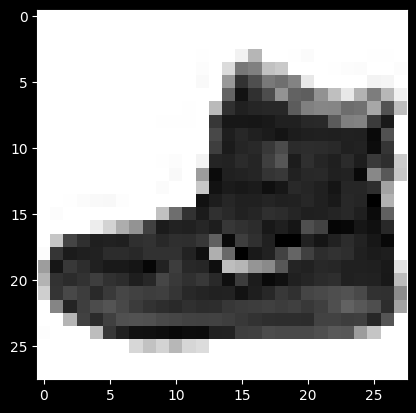

In [16]:
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

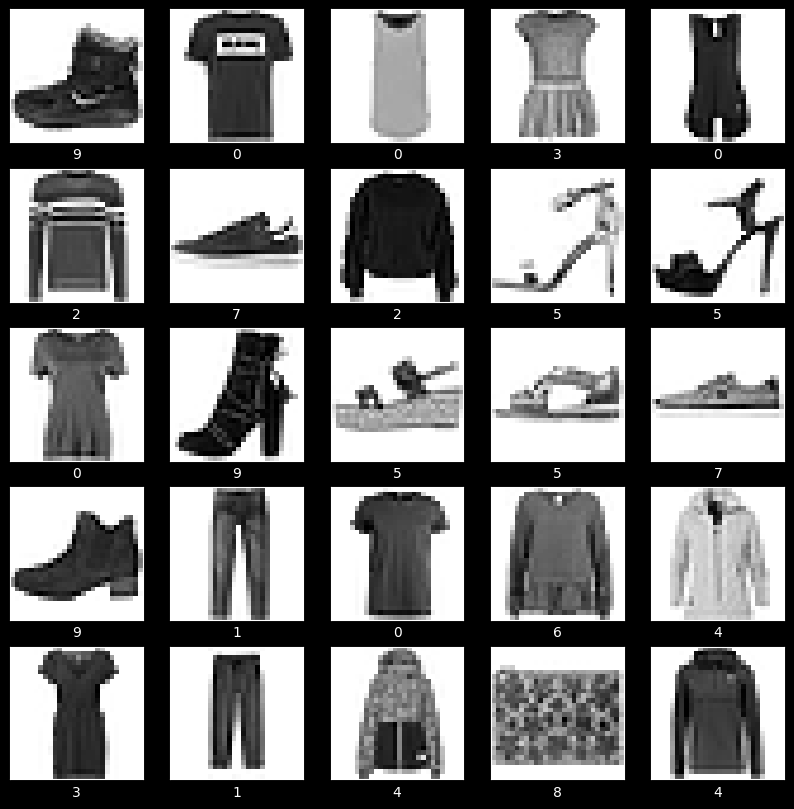

In [17]:
numbers_to_display = 25

num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (10,10))

for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap = plt.cm.binary)
    plt.xlabel(y_train[i])

plt.show()

In [18]:
X_train_with_channels = X_train.reshape(
    X_train.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

X_test_with_channels = X_test.reshape(
    X_test.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

In [19]:
print(f"X_train_with_channels : {X_train_with_channels.shape}")
print(f"X_Test_with_channels : {X_test_with_channels.shape}")

X_train_with_channels : (60000, 28, 28, 1)
X_Test_with_channels : (10000, 28, 28, 1)


In [20]:
X_train_normalized = X_train_with_channels / 255.
X_test_normalized = X_test_with_channels / 255

In [21]:
X_train_normalized[0][18]

array([[0.01176471],
       [0.79215686],
       [0.89411765],
       [0.87843137],
       [0.86666667],
       [0.82745098],
       [0.82745098],
       [0.83921569],
       [0.80392157],
       [0.80392157],
       [0.80392157],
       [0.8627451 ],
       [0.94117647],
       [0.31372549],
       [0.58823529],
       [1.        ],
       [0.89803922],
       [0.86666667],
       [0.7372549 ],
       [0.60392157],
       [0.74901961],
       [0.82352941],
       [0.8       ],
       [0.81960784],
       [0.87058824],
       [0.89411765],
       [0.88235294],
       [0.        ]])

## **ANN (FNN) model part**

In [22]:
FNN_model = Sequential(
    [
        Flatten(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='softmax')
    ]
)

I0000 00:00:1765865477.047272      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765865477.047919      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


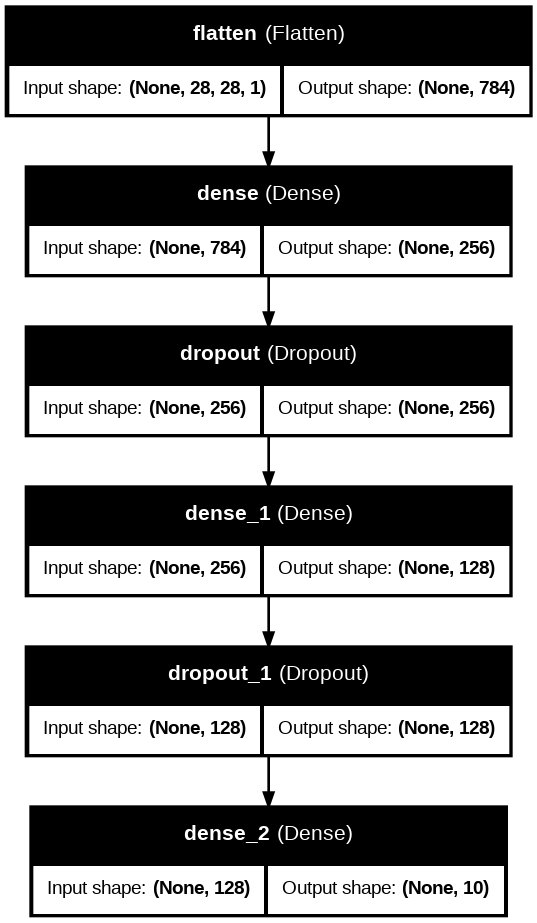

In [23]:
keras.utils.plot_model(
    FNN_model,
    to_file = "model_architecture.png",
    show_shapes = True,
    show_layer_names = True,
    dpi = 96,
    rankdir = "TB"
)

In [24]:
FNN_model.compile(
    optimizer = 'adam',
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
history_FNN = FNN_model.fit(
    X_train_normalized, 
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


I0000 00:00:1765865479.992506     172 service.cc:148] XLA service 0x7df574002aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765865479.993256     172 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765865479.993274     172 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765865480.208598     172 cuda_dnn.cc:529] Loaded cuDNN version 90300


  75/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4362 - loss: 1.6291

I0000 00:00:1765865481.837099     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7269 - loss: 0.7660 - val_accuracy: 0.8508 - val_loss: 0.4082
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8401 - loss: 0.4423 - val_accuracy: 0.8543 - val_loss: 0.3911
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8512 - loss: 0.4055 - val_accuracy: 0.8644 - val_loss: 0.3759
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8616 - loss: 0.3766 - val_accuracy: 0.8640 - val_loss: 0.3688
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8676 - loss: 0.3614 - val_accuracy: 0.8782 - val_loss: 0.3398
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8652 - loss: 0.3542 - val_accuracy: 0.8729 - val_loss: 0.3404
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8728 - loss: 0.3412 - val_accuracy: 0.8688 - val_loss: 0.3447
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.3345 - val_accurac

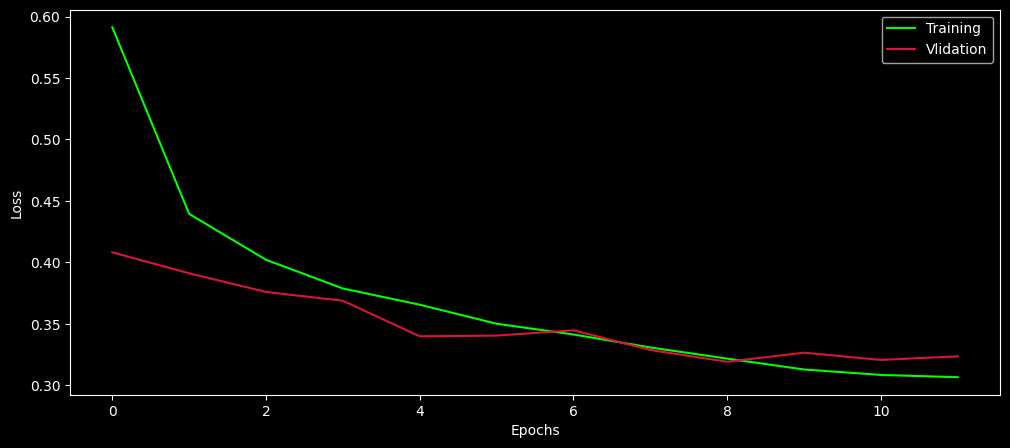

In [27]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['loss'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_loss'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

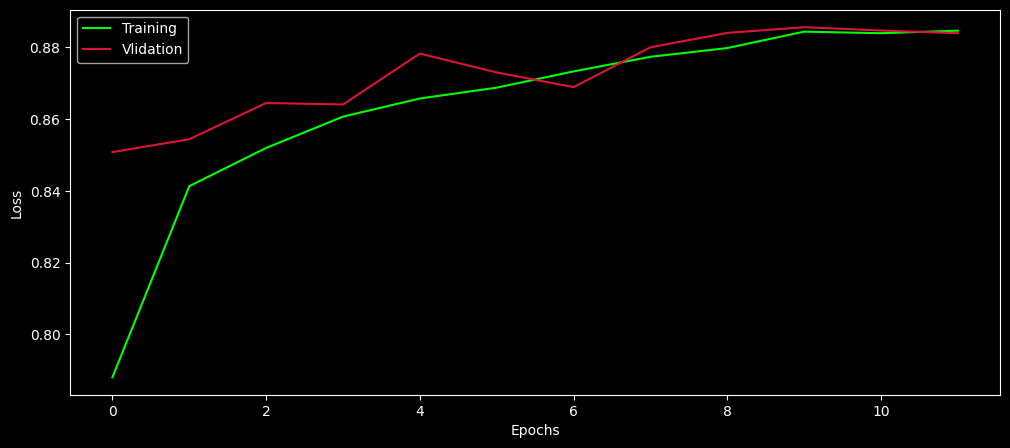

In [28]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['accuracy'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_accuracy'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [29]:
FNN_model.save("FNN_model.keras")

## **CNN model**

In [30]:
CNN_model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Conv2D(
            input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS),
            kernel_size = 5,
            filters = 8,
            strides = 1,
            activation = tf.keras.activations.relu,
            kernel_initializer = tf.keras.initializers.VarianceScaling()
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size = (2, 2),
            strides = (2, 2)
        ),

        tf.keras.layers.Conv2D(
            kernel_size = 5,
            filters = 16,
            strides = 1,
            activation = tf.keras.activations.relu,
            kernel_initializer = tf.keras.initializers.VarianceScaling()
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size = (2, 2),
            strides = (2, 2)
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units = 128,
            activation = tf.keras.activations.relu
        ),

        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            units = 10,
            activation = tf.keras.activations.softmax,
            kernel_initializer = tf.keras.initializers.VarianceScaling()
        )
    ]
)

In [31]:
CNN_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,610 (146.91 KB)

 Trainable params: 37,610 (146.91 KB)

 Non-trainable params: 0 (0.00 B)

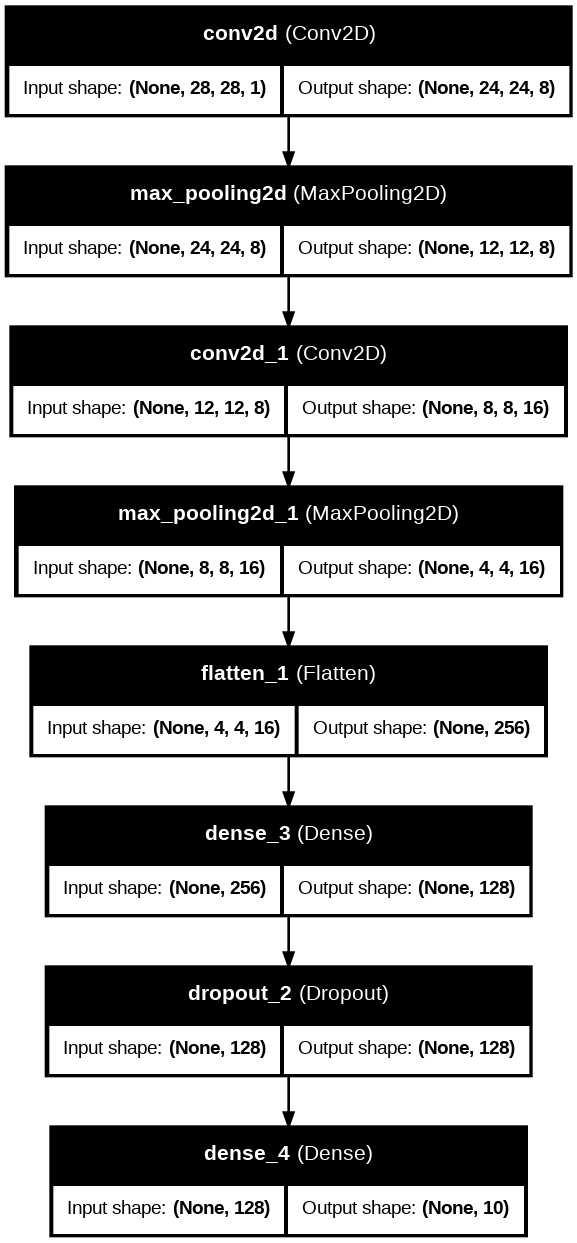

In [32]:
keras.utils.plot_model(
    CNN_model,
    to_file = "model_architecture_CNN.png",
    show_shapes = True,
    show_layer_names = True,
    dpi = 96,
    rankdir = "TB"
)

In [33]:
adam_optimizer = keras.optimizers.Adam(learning_rate = 0.001)

CNN_model.compile(
    optimizer = adam_optimizer,
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [34]:
training_history = CNN_model.fit(
    X_train_normalized,
    y_train,
    epochs = 10,
    validation_data = (X_test_normalized, y_test),
    callbacks = [early_stop]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7079 - loss: 0.7916 - val_accuracy: 0.8479 - val_loss: 0.4176
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8515 - loss: 0.4057 - val_accuracy: 0.8694 - val_loss: 0.3646
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8733 - loss: 0.3506 - val_accuracy: 0.8776 - val_loss: 0.3349
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8825 - loss: 0.3177 - val_accuracy: 0.8831 - val_loss: 0.3185
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8890 - loss: 0.2969 - val_accuracy: 0.8870 - val_loss: 0.3082
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8993 - loss: 0.2720 - val_accuracy: 0.8896 - val_loss: 0.3049
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9034 - loss: 0.2590 - val_accuracy: 0.8963 - val_loss: 0.2901
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9082 - loss: 0.2475 - 

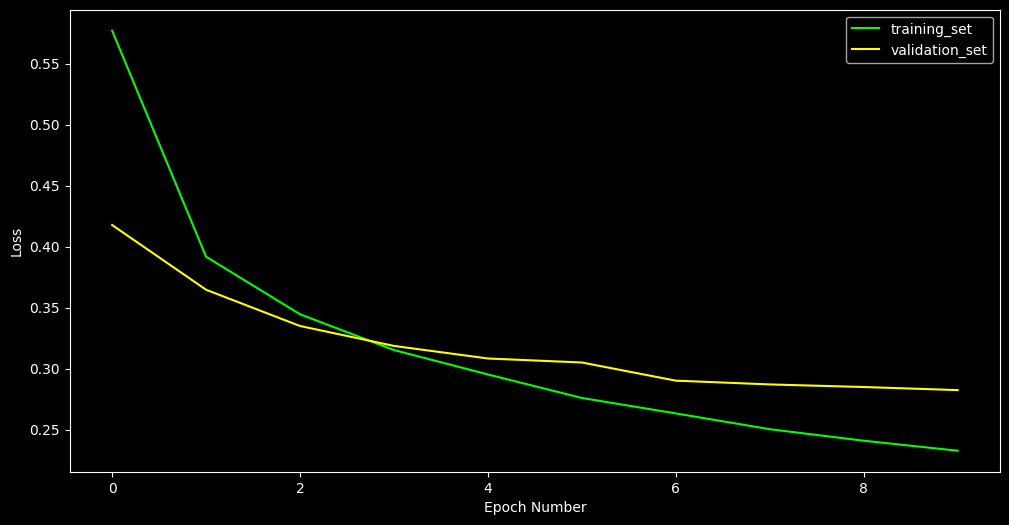

In [35]:
plt.figure(figsize = (12,6))
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], color = 'lime', label = "training_set")
plt.plot(training_history.history['val_loss'], color = 'yellow', label = "validation_set")
plt.legend()
plt.show()

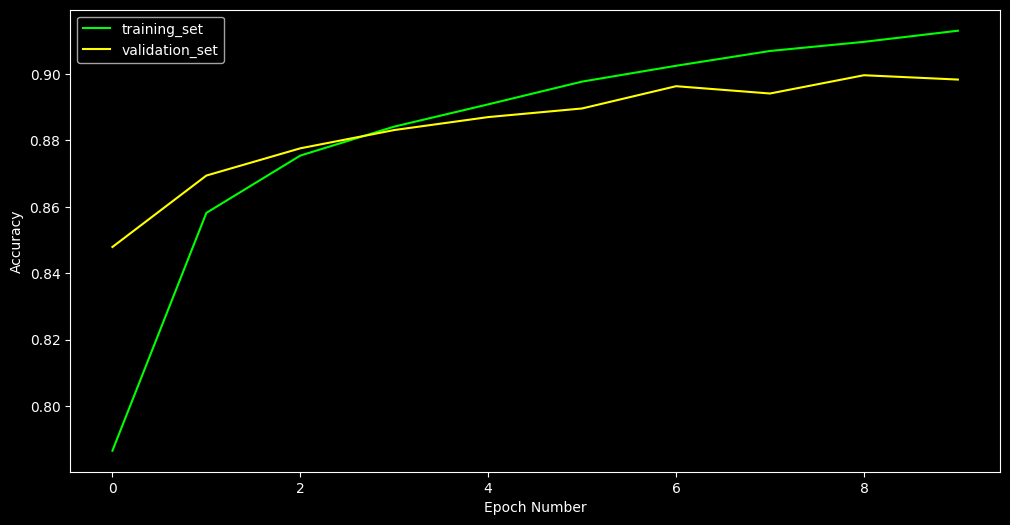

In [36]:
plt.figure(figsize = (12,6))
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], color = 'lime', label = "training_set")
plt.plot(training_history.history['val_accuracy'], color = 'yellow', label = "validation_set")
plt.legend()
plt.show()

In [37]:
CNN_model.save("CNN_model.keras")